In [78]:
#Import necessary packages
import time
import requests
import lxml.html as lx
import re
import pandas as pd
from datetime import datetime
import sqlite3 as sql
from requests.exceptions import HTTPError
import operator as op
from unidecode import unidecode
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## SQL Overview

In this section, we explore the Billboard Chart Rankings, Spotify Weekly Charts, and Apple Music Daily Charts

In [79]:
#Create SQl connection
sqlite_db_path = '../all_data/data.db'  # Name of the table to be created in SQLite
conn = sql.connect(sqlite_db_path)

In [80]:
#View BillboardChart table
pd.read_sql('''SELECT * from BillboardCharts''', conn)

,artist,song_name,rank,artist_link,last_week_rank,peak,weeks_chart,week,chart
0,Flipperachi,FA9LA,1,None,1,1,10,02-28-2026,Billboard Arabic Hot 100
1,DYSTINCT,Yama,2,None,2,1,17,02-28-2026,Billboard Arabic Hot 100
2,Vanco Featuring AYA,Ma Tnsani,3,None,3,2,29,02-28-2026,Billboard Arabic Hot 100
3,"Lege-Cy, Ghaliaa",Msh Awl Marra,4,None,7,4,3,02-28-2026,Billboard Arabic Hot 100
4,DYSTINCT,Ta3al,5,None,4,3,4,02-28-2026,Billboard Arabic Hot 100
...,...,...,...,...,...,...,...,...,...
1645,Don Omar,Danza Kuduro,196,https://www.billboard.com/artist/don-omar/,-,140,37,02-28-2026,Worldwide Top 200 Songs
1646,Jimin,Who,197,https://www.billboard.com/artist/jimin/,-,1,74,02-28-2026,Worldwide Top 200 Songs
1647,Hozier,Too Sweet,198,https://www.billboard.com/artist/hozier/,-,1,98,02-28-2026,Worldwide Top 200 Songs
1648,"Shakira, Wyclef Jean",Hips Don't Lie,199,"https://www.billboard.com/artist/shakira/, htt...",-,134,20,02-28-2026,Worldwide Top 200 Songs


In [81]:
#View Spotify Weekly Streaming Charts Table
pd.read_sql('''SELECT * FROM SpotifyWeeklyStreamingCharts''', conn).head()

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country
0,1,Bad Bunny,DtMF,1,60,45722046,-14850248.0,1549114511,Spotify Weekly Chart Global,02-26-2026,Global
1,2,Bad Bunny,BAILE INoLVIDABLE,2,60,33278386,-10608661.0,1273769628,Spotify Weekly Chart Global,02-26-2026,Global
2,3,Djo,End of Beginning,1,106,32979053,-2245987.0,2225140553,Spotify Weekly Chart Global,02-26-2026,Global
3,4,Bad Bunny,NUEVAYoL,3,60,32180613,-10955089.0,1040380429,Spotify Weekly Chart Global,02-26-2026,Global
4,5,Olivia Dean,Man I Need,3,27,31180371,-1623349.0,792309416,Spotify Weekly Chart Global,02-26-2026,Global


In [82]:
#View Apple Chart Rankings Table
pd.read_sql('''SELECT * FROM AppleChartRankings''', conn)

,rank,artist,song_name,chart_name,date,country
0,1,Bad Bunny,DtMF,Worldwide Apple Music Song,02-27-2026,Worldwide
1,2,Taylor Swift,The Fate of Ophelia,Worldwide Apple Music Song,02-27-2026,Worldwide
2,3,PinkPantheress,Stateside,Worldwide Apple Music Song,02-27-2026,Worldwide
3,4,Dave & Tems,Raindance,Worldwide Apple Music Song,02-27-2026,Worldwide
4,5,Olivia Dean,Man I Need,Worldwide Apple Music Song,02-27-2026,Worldwide
...,...,...,...,...,...,...
62795,196,Holy Ten,Banga (feat. Kimberley Richard),Zimbabwe Apple Music Top Song,02-28-2026,Zimbabwe
62796,197,Jah Prayzah,Chiringiro,Zimbabwe Apple Music Top Song,02-28-2026,Zimbabwe
62797,198,Jah Prayzah,Mandionei,Zimbabwe Apple Music Top Song,02-28-2026,Zimbabwe
62798,199,Saintfloew,Cheka,Zimbabwe Apple Music Top Song,02-28-2026,Zimbabwe


In [83]:
# View all distinct spotify weekly charts
pd.read_sql('''SELECT DISTINCT chart_name FROM SpotifyWeeklyStreamingCharts''', conn)

,chart_name
0,Spotify Weekly Chart Global
1,Spotify Weekly Chart United States
2,Spotify Weekly Chart United Kingdom
3,Spotify Weekly Chart Andorra
4,Spotify Weekly Chart Argentina
...,...
72,Spotify Weekly Chart Ukraine
73,Spotify Weekly Chart United Arab Emirates
74,Spotify Weekly Chart Uruguay
75,Spotify Weekly Chart Venezuela


In [84]:
#View all distinct spotify daily charts
pd.read_sql('''SELECT DISTINCT chart_name FROM SpotifyDailyStreamingCharts''', conn)

,chart_name
0,Spotify Daily Chart Global
1,Spotify Daily Chart United States
2,Spotify Daily Chart United Kingdom
3,Spotify Daily Chart Argentina
4,Spotify Daily Chart Australia
...,...
71,Spotify Daily Chart Ukraine
72,Spotify Daily Chart United Arab Emirates
73,Spotify Daily Chart Uruguay
74,Spotify Daily Chart Venezuela


In [85]:
#View all distinct apple charts
pd.read_sql('''SELECT DISTINCT chart_name FROM AppleChartRankings''', conn)

,chart_name
0,Worldwide Apple Music Song
1,United States Apple Music Top Song
2,United Kingdom Apple Music Top Song
3,Argentina Apple Music Top Song
4,Australia Apple Music Top Song
...,...
153,Uruguay Apple Music Top Song
154,Uzbekistan Apple Music Top Song
155,Venezuela Apple Music Top Song
156,Yemen Apple Music Top Song


## Analysis for Billboard Global 200 from Spotify Data

In this section, we create visualizations (bar plots and scatter plots and correlation matrix) to analyze the relationship between streaming data, country, and billboard chart rank.

In [86]:
# Store spotify weekly table for "02-26-2026" week
spotify = pd.read_sql('''SELECT * FROM SpotifyWeeklyStreamingCharts WHERE date = "02-26-2026"''', conn)

In [87]:
# Store billboard global table for "02-26-2026" week
global_billboard = pd.read_sql('''SELECT * from BillboardCharts WHERE chart = "Worldwide Top 200 Songs"''', conn)

In [88]:
global_billboard

,artist,song_name,rank,artist_link,last_week_rank,peak,weeks_chart,week,chart
0,Bad Bunny,DTMF,1,https://www.billboard.com/artist/bad-bunny/,1,1,59,02-28-2026,Worldwide Top 200 Songs
1,Bad Bunny,Baile Inolvidable,2,https://www.billboard.com/artist/bad-bunny/,2,2,59,02-28-2026,Worldwide Top 200 Songs
2,Bad Bunny,Nuevayol,3,https://www.billboard.com/artist/bad-bunny/,3,3,59,02-28-2026,Worldwide Top 200 Songs
3,Bad Bunny,Titi Me Pregunto,4,https://www.billboard.com/artist/bad-bunny/,5,4,71,02-28-2026,Worldwide Top 200 Songs
4,Olivia Dean,Man I Need,5,None,6,2,26,02-28-2026,Worldwide Top 200 Songs
...,...,...,...,...,...,...,...,...,...
195,Don Omar,Danza Kuduro,196,https://www.billboard.com/artist/don-omar/,-,140,37,02-28-2026,Worldwide Top 200 Songs
196,Jimin,Who,197,https://www.billboard.com/artist/jimin/,-,1,74,02-28-2026,Worldwide Top 200 Songs
197,Hozier,Too Sweet,198,https://www.billboard.com/artist/hozier/,-,1,98,02-28-2026,Worldwide Top 200 Songs
198,"Shakira, Wyclef Jean",Hips Don't Lie,199,"https://www.billboard.com/artist/shakira/, htt...",-,134,20,02-28-2026,Worldwide Top 200 Songs


In [89]:
spotify

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country
0,1,Bad Bunny,DtMF,1,60,45722046,-14850248.0,1549114511,Spotify Weekly Chart Global,02-26-2026,Global
1,2,Bad Bunny,BAILE INoLVIDABLE,2,60,33278386,-10608661.0,1273769628,Spotify Weekly Chart Global,02-26-2026,Global
2,3,Djo,End of Beginning,1,106,32979053,-2245987.0,2225140553,Spotify Weekly Chart Global,02-26-2026,Global
3,4,Bad Bunny,NUEVAYoL,3,60,32180613,-10955089.0,1040380429,Spotify Weekly Chart Global,02-26-2026,Global
4,5,Olivia Dean,Man I Need,3,27,31180371,-1623349.0,792309416,Spotify Weekly Chart Global,02-26-2026,Global
...,...,...,...,...,...,...,...,...,...,...,...
14595,196,Changg,Em Không Hiểu (w/ Minh Huy),27,237,138341,-10117.0,32312825,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam
14596,197,Lil Zpoet,Yêu Từ Đâu Mà Ra,150,20,137045,-1849.0,3332279,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam
14597,198,Sơn Tùng M-TP,Chúng Ta Không Thuộc Về Nhau,60,60,137040,NaN,8636859,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam
14598,199,AMEE,MỘNG YU (w/ RPT MCK),3,76,136984,NaN,25553883,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam


In [90]:
# Define a new function that standardizes song names to remove and collaborations in song name title
def clean_string(song_name):
    new_word = re.findall(r"(\S.*\S)(?= \(w)", song_name)
    return new_word

In [91]:
# For a song in the Billboard Global 200, retrieve all the rows in the spotify weekly table that match that song entry; create a list that stores True/False depending on whether the song in the spotify row matches the current billboard song and return this list.

#We have to clean both the spotify song name and the billboard song name so that the names can be fairly compared between tables (using clean_string() function above).

def get_tables(name):
    list_add =[]
    for column in spotify["song_name"]:
        new_column = clean_string(column)
        if len(new_column) == 0:
            if op.contains(unidecode(column.lower()), unidecode((name).lower())) or op.contains(unidecode(name.lower()), unidecode((column).lower())):
                list_add.append(True)
            else:
                list_add.append(False)
        else:
            new_word = new_column[0]
            if op.contains(unidecode(new_word.lower()), unidecode((name).lower())) or op.contains(unidecode(name.lower()), unidecode((new_word).lower())):
                list_add.append(True)
            else:
                list_add.append(False)
    return list_add

In [92]:
# Use the get_table() function for each song in the global billboard 200 and create a data frame for each song that stores all the different appearances of the billboard song in the different spotify weekly charts.

# From this data frame, compute the total number of listens and standardize per 100000 listens

# Create a dictionary that stores the song billboard rank as the key and the total song listens as the value
# Store the song data frame in a list called song_df
# Also, create a dictionary billboard_rank that stores the name of a song as the key and the rank of the song on the global billboard charts as the value.

# Return the song_count dictionary, song_df, and billboard_rank

def billboard_spotify_song_df():
    song_count = {}
    song_df = []
    billboard_rank = {}

    for i in range(0, global_billboard.shape[0]):
        song_name = global_billboard.iloc[i, 1]
        rank = global_billboard.iloc[i, 2]
        list_add = get_tables(song_name)
        df_song = deepcopy(spotify[list_add])

        #standardize song name
        new_song_name = clean_string(song_name)
        if len(new_song_name) != 0:
            song_name = new_song_name[0]
        new_song_name_list = [song_name] * df_song.shape[0]
        df_song['song_name'] = new_song_name_list

        #Create a new temporary data frame that removes appearances in the global spotify chart
        temp = deepcopy(df_song[df_song['country'] != "Global"])
        temp['billboard_rank'] = [rank] * temp.shape[0]

        #Store rank on global billboard chart
        billboard_rank[song_name] = rank

        #From the adjusted dataframe, compute the total number of listens for the song across all available spotify country charts and standardize by 100000 streams
        total_listens = temp["Streams"].sum()
        song_count[i] = total_listens / 100000
        song_df.append(temp)
    return song_df, song_count, billboard_rank


In [93]:
# Create the spotify_global_song dictionary, song_df, and billboard_rank dictionary
song_count_spotify_list, total_song_count_dic, billboard_rank = billboard_spotify_song_df()

In [94]:
#View first entry in the song_count_spotify_list; data frame for all spotify chart appearances for "DTMF"
song_count_spotify_list[0]

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country,billboard_rank
200,1,Bad Bunny,DTMF,1,60,10565325,-5205274.0,325417108,Spotify Weekly Chart United States,02-26-2026,United States,1
419,20,Bad Bunny,DTMF,3,9,1507125,-702587.0,11779392,Spotify Weekly Chart United Kingdom,02-26-2026,United Kingdom,1
602,3,Bad Bunny,DTMF,1,60,1706009,-440542.0,63978952,Spotify Weekly Chart Argentina,02-26-2026,Argentina,1
817,18,Bad Bunny,DTMF,3,8,947907,-311073.0,6033739,Spotify Weekly Chart Australia,02-26-2026,Australia,1
1000,1,Bad Bunny,DTMF,1,44,235718,-96221.0,4649829,Spotify Weekly Chart Austria,02-26-2026,Austria,1
1400,1,Bad Bunny,DTMF,1,57,383341,-87372.0,10305074,Spotify Weekly Chart Belgium,02-26-2026,Belgium,1
1603,4,Bad Bunny,DTMF,1,60,122643,-10660.0,7503097,Spotify Weekly Chart Bolivia,02-26-2026,Bolivia,1
1826,27,Bad Bunny,DTMF,14,11,3239191,-86077.0,25604657,Spotify Weekly Chart Brazil,02-26-2026,Brazil,1
2063,64,Bad Bunny,DTMF,15,9,25729,-9801.0,232634,Spotify Weekly Chart Bulgaria,02-26-2026,Bulgaria,1
2200,1,Bad Bunny,DTMF,1,33,1424725,-689053.0,23784765,Spotify Weekly Chart Canada,02-26-2026,Canada,1


In [95]:
#View Dictionary of total song listens by billboard song rank
total_song_count_dic

{0: np.float64(428.98095),
 1: np.float64(339.7869),
 2: np.float64(322.22623),
 3: np.float64(271.66666),
 4: np.float64(266.17902),
 5: np.float64(301.59275),
 6: np.float64(217.67484),
 7: np.float64(183.04041),
 8: np.float64(255.86032),
 9: np.float64(310.06662),
 10: np.float64(144.83783),
 11: np.float64(296.6586),
 12: np.float64(201.06075),
 13: np.float64(192.7151),
 14: np.float64(144.54358),
 15: np.float64(183.24876),
 16: np.float64(224.6225),
 17: np.float64(164.66296),
 18: np.float64(130.40377),
 19: np.float64(185.35635),
 20: np.float64(194.81079),
 21: np.float64(154.34659),
 22: np.float64(136.94888),
 23: np.float64(208.40844),
 24: np.float64(152.3478),
 25: np.float64(124.04511),
 26: np.float64(114.32669),
 27: np.float64(178.8026),
 28: np.float64(185.16739),
 29: np.float64(114.17865),
 30: np.float64(183.55882),
 31: np.float64(119.9725),
 32: np.float64(70.38375),
 33: np.float64(94.51575),
 34: np.float64(34.37199),
 35: np.float64(93.82768),
 36: np.float

## Correlation

In [96]:
# From the data frames for each song in the global 200, create one joint data frame with all chart appearances for all songs in the global 200.
bill_spotify = pd.concat(song_count_spotify_list)

In [97]:
bill_spotify

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country,billboard_rank
200,1,Bad Bunny,DTMF,1,60,10565325,-5205274.0,325417108,Spotify Weekly Chart United States,02-26-2026,United States,1.0
419,20,Bad Bunny,DTMF,3,9,1507125,-702587.0,11779392,Spotify Weekly Chart United Kingdom,02-26-2026,United Kingdom,1.0
602,3,Bad Bunny,DTMF,1,60,1706009,-440542.0,63978952,Spotify Weekly Chart Argentina,02-26-2026,Argentina,1.0
817,18,Bad Bunny,DTMF,3,8,947907,-311073.0,6033739,Spotify Weekly Chart Australia,02-26-2026,Australia,1.0
1000,1,Bad Bunny,DTMF,1,44,235718,-96221.0,4649829,Spotify Weekly Chart Austria,02-26-2026,Austria,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11796,197,Lana Del Rey,Young And Beautiful,4,66,49672,385.0,972713,Spotify Weekly Chart Singapore,02-26-2026,Singapore,200.0
12999,200,Lana Del Rey,Young And Beautiful,131,26,57438,-2442.0,1523825,Spotify Weekly Chart Switzerland,02-26-2026,Switzerland,200.0
13418,19,UZI,Young And Beautiful,1,5,1601220,-533917.0,16390266,Spotify Weekly Chart Turkey,02-26-2026,Turkey,200.0
13594,195,Poizi,Young And Beautiful,9,44,529068,-128838.0,68962002,Spotify Weekly Chart Turkey,02-26-2026,Turkey,200.0


In [98]:
# Compute a correlation matrix to see if any variable is highly correlated with Billboard rank
bill_corr = bill_spotify.corr(numeric_only=True)

In [99]:
# Rename columns and rows for the final visualization
bill_corr = bill_corr.rename(columns={"rank" : "Rank", "peak" : "Peak", "weeks": "Weeks", "billboard_rank": "Billboard Rank"}, index = {"rank" : "Rank", "peak" : "Peak", "weeks": "Weeks", "billboard_rank": "Billboard Rank"})

In [100]:
bill_corr

,Rank,Peak,Weeks,Streams,Streams+,Total,Billboard Rank
Rank,1.000000,0.491613,0.086545,-0.201723,0.117621,0.011389,0.281313
Peak,0.491613,1.000000,-0.264677,-0.155843,0.110887,-0.198924,0.156451
Weeks,0.086545,-0.264677,1.000000,0.014503,0.036113,0.376320,0.216421
Streams,-0.201723,-0.155843,0.014503,1.000000,-0.602247,0.558542,-0.036529
Streams+,0.117621,0.110887,0.036113,-0.602247,1.000000,-0.236094,0.075489
Total,0.011389,-0.198924,0.376320,0.558542,-0.236094,1.000000,0.073438
Billboard Rank,0.281313,0.156451,0.216421,-0.036529,0.075489,0.073438,1.000000


Text(0.5, 1.0, 'Correlation Matrix Between Spotify Variables and Billboard Rank')

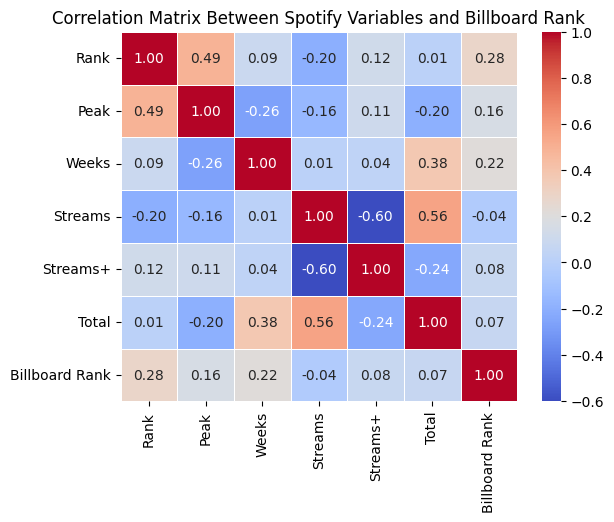

In [101]:
# Visualize the correlation values using a heat map
sns.heatmap(bill_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Between Spotify Variables and Billboard Rank")

## Analysis by Country

In this section, we specifically explore the relationship between country and streams for billboard chart songs.

In [102]:
#Create a pandas series from the total listens dictionary
song_count_series = pd.Series(total_song_count_dic).rename("total_counts")

In [103]:
song_count_series

0      428.98095
1      339.78690
2      322.22623
3      271.66666
4      266.17902
         ...    
195     16.47650
196    259.60925
197     24.50488
198     23.44560
199     47.02514
Name: total_counts, Length: 200, dtype: float64

In [104]:
# Join all of the data frames for each song in the global 200
# These stores all relevant charts to the global 200 songs in one location.
bill_spotify = pd.concat(song_count_spotify_list)

In [105]:
bill_spotify

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country,billboard_rank
200,1,Bad Bunny,DTMF,1,60,10565325,-5205274.0,325417108,Spotify Weekly Chart United States,02-26-2026,United States,1.0
419,20,Bad Bunny,DTMF,3,9,1507125,-702587.0,11779392,Spotify Weekly Chart United Kingdom,02-26-2026,United Kingdom,1.0
602,3,Bad Bunny,DTMF,1,60,1706009,-440542.0,63978952,Spotify Weekly Chart Argentina,02-26-2026,Argentina,1.0
817,18,Bad Bunny,DTMF,3,8,947907,-311073.0,6033739,Spotify Weekly Chart Australia,02-26-2026,Australia,1.0
1000,1,Bad Bunny,DTMF,1,44,235718,-96221.0,4649829,Spotify Weekly Chart Austria,02-26-2026,Austria,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11796,197,Lana Del Rey,Young And Beautiful,4,66,49672,385.0,972713,Spotify Weekly Chart Singapore,02-26-2026,Singapore,200.0
12999,200,Lana Del Rey,Young And Beautiful,131,26,57438,-2442.0,1523825,Spotify Weekly Chart Switzerland,02-26-2026,Switzerland,200.0
13418,19,UZI,Young And Beautiful,1,5,1601220,-533917.0,16390266,Spotify Weekly Chart Turkey,02-26-2026,Turkey,200.0
13594,195,Poizi,Young And Beautiful,9,44,529068,-128838.0,68962002,Spotify Weekly Chart Turkey,02-26-2026,Turkey,200.0


In [106]:
#Normalize the total number of streams per 1000000 listens
bill_spotify['Streams'] = bill_spotify["Streams"] / 100000

In [107]:
# For each country available in the spotify weekly charts, compute the total number, the average, and the standard deviation of listens they contributed across all songs in the global billboard hot 200

# Also compute the standard deviation for each song among all charts that contain that song for later use.

sum_spotify_country = bill_spotify.groupby("country").sum(numeric_only=True)
mean_spotify_country = bill_spotify.groupby("country").mean(numeric_only=True)
sd_spotify_country = bill_spotify.groupby("country")['Streams'].std()
sd_spotify_song = bill_spotify.groupby("song_name")["Streams"].std()

In [108]:
mean_spotify_country

,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
country,,,,,,,
Argentina,50.363636,12.666667,50.363636,9.306998,-199516.903226,4.531961e+07,72.333333
Australia,84.942623,32.959016,92.049180,6.142809,-27070.882353,4.956396e+07,82.532787
Austria,86.858586,38.595960,62.868687,0.811721,-6391.307692,4.839922e+06,81.424242
Belarus,97.714286,57.666667,48.761905,0.245538,2077.380952,1.957450e+06,99.380952
Belgium,78.230000,30.020000,88.770000,1.458755,-10219.010101,1.083593e+07,79.690000
...,...,...,...,...,...,...,...
United Kingdom,83.756303,30.369748,86.277311,9.811587,-68169.525424,7.784985e+07,81.042017
United States,77.017391,22.721739,63.330435,37.162717,-441750.657895,2.431726e+08,75.234783
Uruguay,53.870968,20.193548,44.709677,0.703587,-10510.580645,3.348443e+06,76.451613


In [109]:
sum_spotify_country

,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
country,,,,,,,
Argentina,1662,418,1662,307.13092,-6185024.0,1495546996,2387.0
Australia,10363,4021,11230,749.42269,-3221435.0,6046802517,10069.0
Austria,8599,3821,6224,80.36034,-581609.0,479152247,8061.0
Belarus,2052,1211,1024,5.15629,43625.0,41106456,2087.0
Belgium,7823,3002,8877,145.87549,-1011682.0,1083592863,7969.0
...,...,...,...,...,...,...,...
United Kingdom,9967,3614,10267,1167.57885,-8044004.0,9264132457,9644.0
United States,8857,2613,7283,4273.71247,-50359575.0,27964848453,8652.0
Uruguay,1670,626,1386,21.81119,-325828.0,103801720,2370.0


In [110]:
sd_spotify_country

country
Argentina          5.002964
Australia          3.402335
Austria            0.426796
Belarus            0.296759
Belgium            0.723335
                    ...    
United Kingdom     5.622522
United States     16.064675
Uruguay            0.362237
Venezuela          0.687764
Vietnam            5.799618
Name: Streams, Length: 72, dtype: float64

In [111]:
sd_spotify_song

song_name
(When You Gonna) Give It Up To Me     3.564715
12 To 12                              7.498193
4 Raws                                7.576200
505                                  11.707911
7-3                                  33.309667
                                       ...    
Young And Beautiful                   6.714627
Yukon                                 7.361476
Zoo                                   3.318010
like JENNIE                           4.963307
wgft                                  2.438514
Name: Streams, Length: 199, dtype: float64

### Visualization: Country versus Mean Streams

In [112]:
# Sort averages to get top twenty songs
sorted_spotify_country = mean_spotify_country["Streams"].sort_values(ascending=False).reset_index()

In [113]:
top_twenty_countries = sorted_spotify_country[0:20]

In [114]:
top_twenty_countries

,country,Streams
0,Mexico,39.550552
1,United States,37.162717
2,Brazil,20.780653
3,Indonesia,15.894278
4,India,14.329071
5,Philippines,12.987115
6,United Kingdom,9.811587
7,Japan,9.719715
8,Argentina,9.306998
9,Turkey,8.973885


In [115]:
# Reverse the order to facilitate plotting in bar plot
reverse_sorted = top_twenty_countries.sort_values(by = "Streams", ascending=True)

In [116]:
# Retrieve the standard deviation for each of these songs
sd_top_20 = pd.Series([sd_spotify_country[country_name] for country_name in reverse_sorted['country']])

Text(0.5, 1.0, 'Average Weekly Number of Streams by Country (Top 20 Countries)')

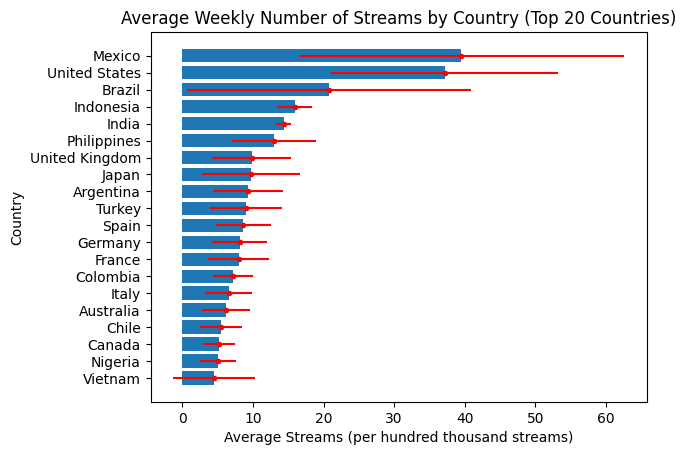

In [117]:
# Plot the average number of streams for the highest averages by country
plt.barh(y = reverse_sorted.iloc[0:20, 0], width = reverse_sorted.iloc[0:20, 1], align = 'center')
plt.xlabel("Average Streams (per hundred thousand streams)")
plt.ylabel("Country")
plt.errorbar(y = reverse_sorted.iloc[0:20, 0], x = reverse_sorted.iloc[0:20, 1], xerr= sd_top_20, color = 'r', fmt='.')
plt.title("Average Weekly Number of Streams by Country (Top 20 Countries)")

### Visualization: Country versus Total Streams

In [118]:
# Sort sums to get top twenty songs
sum_sorted_spotify_country = sum_spotify_country["Streams"].sort_values(ascending=False).reset_index()

In [119]:
sum_top_twenty_countries = sum_sorted_spotify_country[0:20]

In [120]:
# Reverse for plotting purposes
sum_reverse_sorted = sum_top_twenty_countries.sort_values(by = "Streams", ascending=True)

In [121]:
sum_top_twenty_countries

,country,Streams
0,United States,4273.71247
1,Indonesia,1764.26482
2,Mexico,1463.37044
3,United Kingdom,1167.57885
4,Australia,749.42269
5,Philippines,701.30422
6,Canada,666.26544
7,Turkey,610.22421
8,Germany,607.63778
9,Brazil,457.17437


Text(0.5, 1.0, 'Total Weekly Number of Streams by Country (Top 20 Countries)')

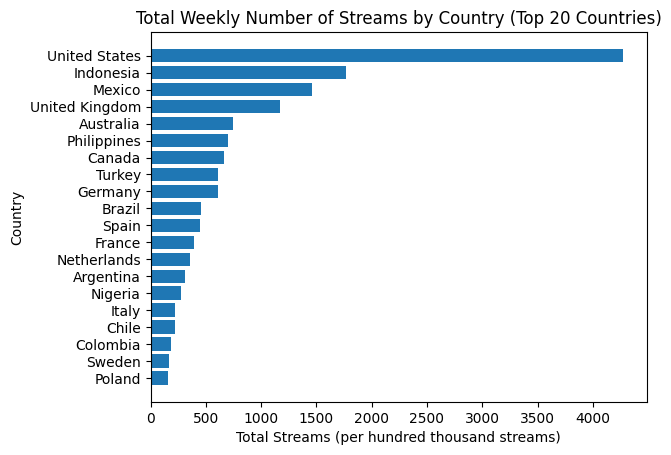

In [122]:
# Plot the total number of streams for the highest totals by country
plt.barh(y = sum_reverse_sorted.iloc[0:20, 0], width = sum_reverse_sorted.iloc[0:20, 1], align = 'center')
plt.xlabel("Total Streams (per hundred thousand streams)")
plt.ylabel("Country")
plt.title("Total Weekly Number of Streams by Country (Top 20 Countries)")

## Analysis by Song Name

### Visualization: Song versus Streaming Statistics

In [123]:
#Compute the average number of streams for each song in Billboard Chart
song_average_all_countries_spotify = bill_spotify.groupby("song_name").mean(numeric_only=True).reset_index().sort_values("song_name")

In [124]:
billboard_rank_df = pd.Series(billboard_rank).to_frame().reset_index()

In [125]:
# store the original billboard rank of each of the songs
song_average_all_countries_spotify['billboard_rank'] = billboard_rank_df.sort_values("index").reset_index(drop=True)[0]

In [126]:
song_average_all_countries_spotify

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
0,(When You Gonna) Give It Up To Me,78.595238,68.000000,9.071429,2.553843,-12397.975000,4.284574e+06,102
1,12 To 12,38.714286,20.357143,29.821429,4.430182,-19558.035714,1.365062e+07,26
2,4 Raws,93.761905,29.904762,16.190476,2.981163,-25515.857143,5.481212e+06,125
3,505,122.800000,31.300000,199.500000,5.060310,-33513.200000,1.023471e+08,132
4,7-3,22.400000,11.600000,9.000000,16.274012,-195038.000000,1.729392e+07,116
...,...,...,...,...,...,...,...,...
194,Young And Beautiful,135.888889,49.111111,46.111111,5.225016,-82291.888889,5.890100e+07,74
195,Yukon,139.400000,23.300000,22.100000,4.583484,-63488.800000,1.990086e+07,200
196,Zoo,91.307692,46.923077,20.769231,2.726012,-20558.076923,1.192589e+07,79
197,like JENNIE,76.111111,3.000000,67.000000,2.692257,-8996.333333,5.245837e+07,65


In [127]:
song_average_all_countries_spotify.sort_values("rank", ascending = True)

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
91,La Villa,21.105263,9.368421,20.263158,6.640491,-13756.421053,2.640014e+07,95
4,7-3,22.400000,11.600000,9.000000,16.274012,-195038.000000,1.729392e+07,116
41,DTMF,23.966667,7.833333,33.766667,7.149682,-227255.650000,2.320823e+07,1
39,Cuando No Era Cantante,29.371429,16.857143,15.942857,6.761616,-58205.742857,1.566829e+07,92
21,Be Her,30.500000,28.500000,2.000000,27.114925,-157233.000000,5.580218e+06,54
...,...,...,...,...,...,...,...,...
193,Yo Perreo Sola,164.000000,25.333333,93.166667,3.930460,-47582.000000,8.333611e+07,67
70,Greedy,167.500000,18.125000,98.250000,1.826990,-22997.666667,3.884753e+07,162
160,Take On Me,169.833333,165.833333,3.000000,1.052737,5342.000000,3.014447e+05,194
14,As It Was,171.000000,1.000000,147.090909,1.353116,-6166.875000,4.817819e+07,107


Text(0.5, 1.0, 'Song Rank v. Streams')

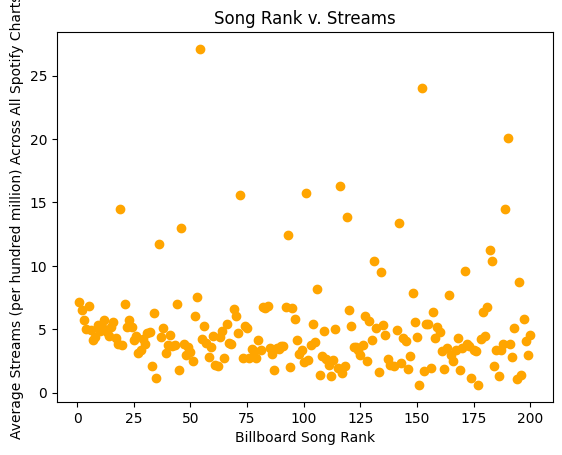

In [128]:
# Plot the relationship between song rank and average number of streams (position on x-axis corresponds to rank in billboard chart)

plt.scatter(song_average_all_countries_spotify['billboard_rank'], song_average_all_countries_spotify["Streams"], color = "orange")

plt.xlabel("Billboard Song Rank")
plt.ylabel("Average Streams (per hundred million) Across All Spotify Charts")
plt.title("Song Rank v. Streams")

Text(0.5, 1.0, 'Song Billboard Rank v. Average Spotify Rank')

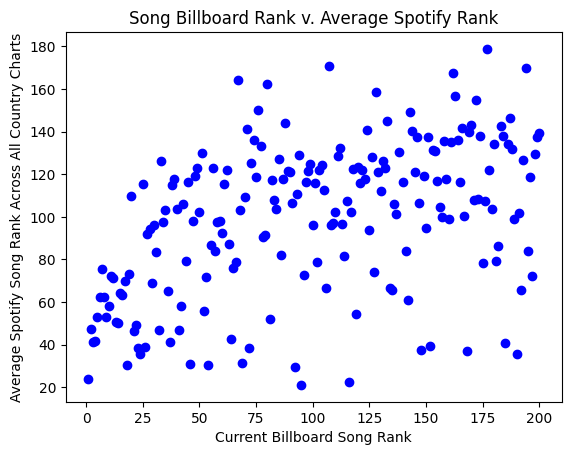

In [129]:
# Plot the relationship between song rank and average rank on spotify charts (position on x-axis corresponds to rank in billboard chart)

plt.scatter(song_average_all_countries_spotify['billboard_rank'], song_average_all_countries_spotify["rank"], color = "blue")

plt.xlabel("Current Billboard Song Rank")
plt.ylabel("Average Spotify Song Rank Across All Country Charts")
plt.title("Song Billboard Rank v. Average Spotify Rank")

In [130]:
#Compute total sum of streams for each song
song_sum_all_countries_spotify = bill_spotify.groupby("song_name").sum(numeric_only=True).sort_values("song_name").reset_index()

In [131]:
song_sum_all_countries_spotify

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
0,(When You Gonna) Give It Up To Me,3301,2856,381,107.26142,-495919.0,179952107,4284.0
1,12 To 12,1084,570,835,124.04511,-547625.0,382217227,728.0
2,4 Raws,1969,628,340,62.60443,-535833.0,115105457,2625.0
3,505,1228,313,1995,50.60310,-335132.0,1023470809,1320.0
4,7-3,112,58,45,81.37006,-975190.0,86469621,580.0
...,...,...,...,...,...,...,...,...
194,Young And Beautiful,1223,442,415,47.02514,-740627.0,530108959,1800.0
195,Yukon,1394,233,221,45.83484,-634888.0,199008629,790.0
196,Zoo,1187,610,270,35.43815,-267255.0,155036610,845.0
197,like JENNIE,685,27,603,24.23031,-80967.0,472125324,1377.0


In [132]:
# Add rank column to data frame for plotting
song_sum_all_countries_spotify['billboard_rank'] = billboard_rank_df.sort_values("index").reset_index(drop=True)[0]

In [133]:
song_sum_all_countries_spotify

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
0,(When You Gonna) Give It Up To Me,3301,2856,381,107.26142,-495919.0,179952107,102
1,12 To 12,1084,570,835,124.04511,-547625.0,382217227,26
2,4 Raws,1969,628,340,62.60443,-535833.0,115105457,125
3,505,1228,313,1995,50.60310,-335132.0,1023470809,132
4,7-3,112,58,45,81.37006,-975190.0,86469621,116
...,...,...,...,...,...,...,...,...
194,Young And Beautiful,1223,442,415,47.02514,-740627.0,530108959,74
195,Yukon,1394,233,221,45.83484,-634888.0,199008629,200
196,Zoo,1187,610,270,35.43815,-267255.0,155036610,79
197,like JENNIE,685,27,603,24.23031,-80967.0,472125324,65


Text(0.5, 1.0, 'Song Rank v. Total Streams')

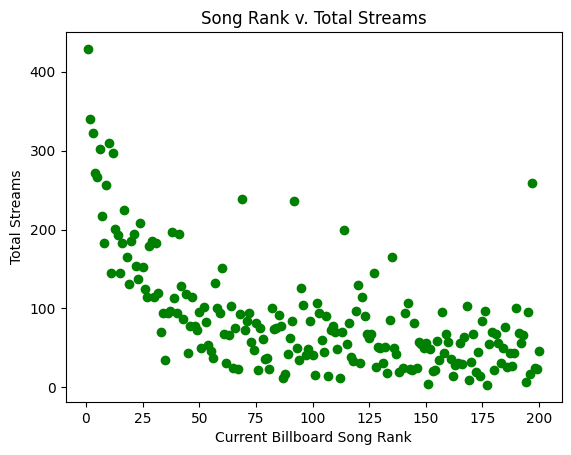

In [134]:
# Plot the billboard rank versus the total number of streams for each song
plt.scatter(song_sum_all_countries_spotify['billboard_rank'], song_sum_all_countries_spotify["Streams"], color = "green")

plt.xlabel("Current Billboard Song Rank")
plt.ylabel("Total Streams")
plt.title("Song Rank v. Total Streams")

### Visualization : Song versus Total Streams (Top 20)

In [135]:
# Compute total number of streams for each song and select top 20
top_20_sum = song_sum_all_countries_spotify.sort_values("Streams", ascending = False)[0:20]

In [136]:
top_20_sum

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
41,DTMF,1438,470,2026,428.98095,-13635339.0,1392493831,1
18,Baile Inolvidable,2467,842,1760,339.78690,-9966194.0,1560138836,2
116,Nuevayol,2301,759,1928,322.22623,-10073727.0,1375305328,3
57,End Of Beginning,3725,965,3399,310.06662,-1920299.0,1679010913,10
165,The Fate Of Ophelia,3794,435,1578,301.59275,-1513191.0,1480958956,6
147,So Easy (To Fall In Love),3707,2941,1057,296.65860,-540358.0,955962055,12
172,Titi Me Pregunto,2262,831,2024,271.66666,-9888310.0,1308378181,4
100,Man I Need,2064,1438,912,266.17902,-1470640.0,683845558,5
188,Who,3248,1371,3276,259.60925,-206253.0,1589262423,197
56,EOO,2541,1093,1507,255.86032,-7571834.0,916849652,9


In [137]:
# Reverse order for plotting purposes
reverse_sorted_sum = top_20_sum.sort_values(by = "Streams", ascending=True)

In [138]:
reverse_sorted_sum

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
15,Babydoll,2017,1649,745,194.17535,1640979.0,700457134,41
47,Die On This Hill,1305,897,495,194.81079,-714494.0,593779731,21
26,Body,4488,2007,1781,197.47761,-1246805.0,1280382341,38
82,Iris Out,3266,2047,3790,199.57102,-1162254.0,1504729549,114
187,Where Is My Husband!,2132,1184,905,201.06075,-1588582.0,500632567,13
154,Stateside,1431,1422,276,208.40844,6618554.0,98104088,24
68,Golden,3932,1347,1815,217.67484,-1777000.0,1546643398,7
16,Back To Friends,3627,1736,2321,224.62250,-720420.0,1266609260,17
39,Cuando No Era Cantante,1028,590,558,236.65656,-2037201.0,548390247,92
40,Cuando No Era Cantante (Remix),1130,594,576,238.64232,-2011152.0,554824333,69


In [139]:
sd_top_20_sum = pd.Series([sd_spotify_song[country_name] for country_name in reverse_sorted_sum['song_name']])

In [140]:
# Retrieve the original rank for selected songs
top_20_bill_rank = song_sum_all_countries_spotify.sort_values("billboard_rank", ascending = True)[0:20]

In [141]:
top_20_bill_rank

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
41,DTMF,1438,470,2026,428.98095,-13635339.0,1392493831,1
18,Baile Inolvidable,2467,842,1760,339.78690,-9966194.0,1560138836,2
116,Nuevayol,2301,759,1928,322.22623,-10073727.0,1375305328,3
172,Titi Me Pregunto,2262,831,2024,271.66666,-9888310.0,1308378181,4
100,Man I Need,2064,1438,912,266.17902,-1470640.0,683845558,5
165,The Fate Of Ophelia,3794,435,1578,301.59275,-1513191.0,1480958956,6
68,Golden,3932,1347,1815,217.67484,-1777000.0,1546643398,7
123,Ordinary,2628,731,2102,183.04041,-1823993.0,1431839521,8
56,EOO,2541,1093,1507,255.86032,-7571834.0,916849652,9
57,End Of Beginning,3725,965,3399,310.06662,-1920299.0,1679010913,10


In [142]:
# Reverse the order of the rank as well
reverse_sorted_sum_bil_rank = top_20_bill_rank.sort_values(by = "billboard_rank", ascending=False)

In [143]:
reverse_sorted_sum_bil_rank

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
48,Die With A Smile,5389,234,3985,185.35635,-1864015.0,3387850153,20
32,Choosin' Texas,658,584,226,130.40377,-249712.0,268436385,19
133,Raindance,1313,1087,498,164.66296,-717975.0,191855339,18
16,Back To Friends,3627,1736,2321,224.62250,-720420.0,1266609260,17
179,Voy A Llevarte Pa PR,2082,605,1528,183.24876,-5899767.0,1142999717,16
76,I Just Might,1797,636,196,144.54358,-298803.0,133504359,15
98,Lush Life,2150,740,4125,192.71510,-1806760.0,1162669437,14
187,Where Is My Husband!,2132,1184,905,201.06075,-1588582.0,500632567,13
147,So Easy (To Fall In Love),3707,2941,1057,296.65860,-540358.0,955962055,12
122,Opalite,2026,199,760,144.83783,-1075459.0,905001381,11


In [144]:
sd_top_20_sum_bill_rank = pd.Series([sd_spotify_song[country_name] for country_name in reverse_sorted_sum_bil_rank['song_name']])

Text(0.5, 1.0, 'Total Weekly Number of Streams by Song (Top 20 Songs by Streams)')

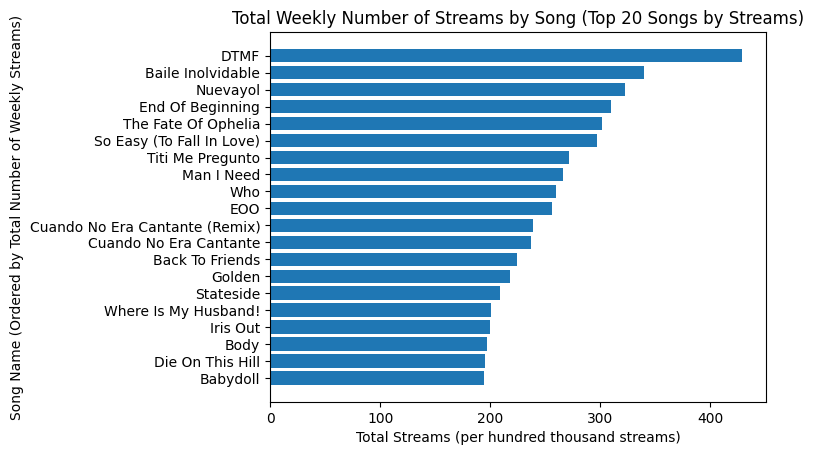

In [145]:
# Plot the total number of streams for the top 20 streamed songs
plt.barh(y = reverse_sorted_sum.iloc[0:20, 0], width = reverse_sorted_sum.iloc[0:20, 4], align = 'center')
plt.xlabel("Total Streams (per hundred thousand streams)")
plt.ylabel("Song Name (Ordered by Total Number of Weekly Streams)")
#plt.errorbar(y = reverse_sorted_sum.iloc[0:20, 0], x = reverse_sorted_sum.iloc[0:20, 4], xerr= sd_top_20_sum, color = 'r', fmt='.')
plt.title("Total Weekly Number of Streams by Song (Top 20 Songs by Streams)")

Text(0.5, 1.0, 'Total Weekly Number of Streams by Song (Top 20 Songs by Global Billboard Ranking)')

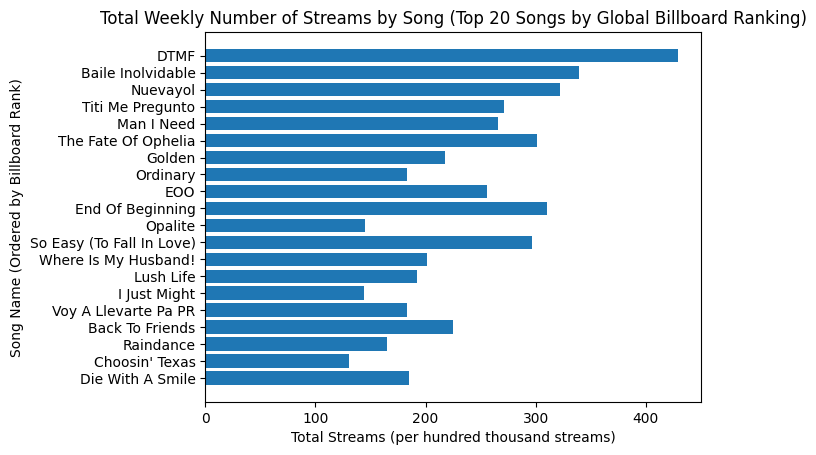

In [146]:
# Plot the total number of streams for the top 20 Billboard Global 200 songs
plt.barh(y = reverse_sorted_sum_bil_rank.iloc[0:20, 0], width = reverse_sorted_sum_bil_rank.iloc[0:20, 4], align = 'center')
plt.xlabel("Total Streams (per hundred thousand streams)")
plt.ylabel("Song Name (Ordered by Billboard Rank)")
#plt.errorbar(y = reverse_sorted_sum_bil_rank.iloc[0:20, 0], x = reverse_sorted_sum_bil_rank.iloc[0:20, 4], xerr= sd_top_20_sum_bill_rank, color = 'r', fmt='.')
plt.title("Total Weekly Number of Streams by Song (Top 20 Songs by Global Billboard Ranking)")

### Visualization: Song versus Average Streams (Top 20)

In [147]:
# Compute song averages
song_mean_all_countries_spotify = bill_spotify.groupby("song_name").mean(numeric_only=True).sort_values("song_name").reset_index()

In [148]:
# Select top 20
song_mean_top20 = song_mean_all_countries_spotify.sort_values("Streams", ascending = False)[0:20]

In [149]:
reverse_song_mean_top20 = song_mean_top20.sort_values(by = "Streams", ascending=True)

In [150]:
sd_top_20_mean_song = pd.Series([sd_spotify_song[country_name] for country_name in reverse_song_mean_top20['song_name']])

Text(0.5, 1.0, 'Average Weekly Number of Streams by Song')

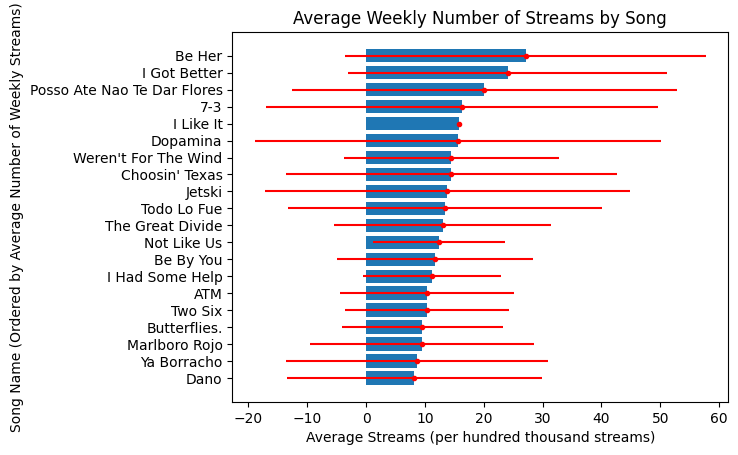

In [151]:
# Plot top twenty song in terms of streaming averages
plt.barh(y = reverse_song_mean_top20.iloc[0:20, 0], width = reverse_song_mean_top20.iloc[0:20, 4], align = 'center')
plt.xlabel("Average Streams (per hundred thousand streams)")
plt.ylabel("Song Name (Ordered by Average Number of Weekly Streams)")
plt.errorbar(y = reverse_song_mean_top20.iloc[0:20, 0], x = reverse_song_mean_top20.iloc[0:20, 4], xerr= sd_top_20_mean_song, color = 'r', fmt='.')
plt.title("Average Weekly Number of Streams by Song")

In [152]:
# Select streaming averages for top 20 songs in Billboard Global 200 chart
mean_bill_rank_20 = song_mean_all_countries_spotify.sort_values("billboard_rank", ascending = True)[0:20]

In [153]:
reverse_mean_bill_rank_20 = mean_bill_rank_20.sort_values(by = "billboard_rank", ascending=False)

In [154]:
sd_top_20_mean_bill_rank = pd.Series([sd_spotify_song[country_name] for country_name in reverse_mean_bill_rank_20['song_name']])

Text(0.5, 1.0, 'Average Weekly Number of Streams by Billboard Rank (Top 20 Songs)')

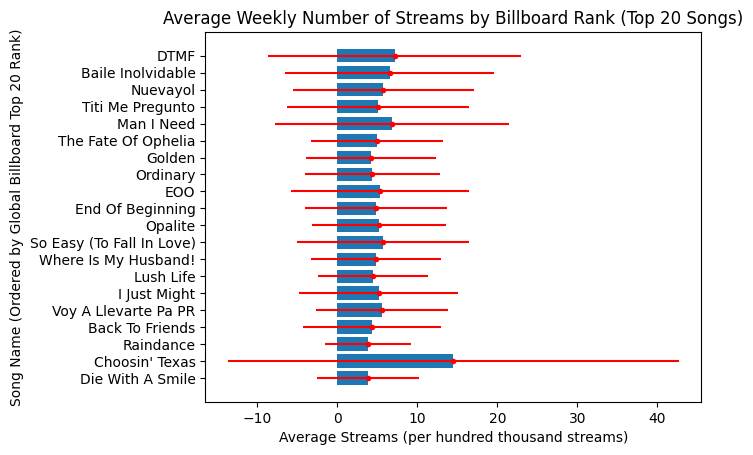

In [155]:
# Plot the streaming averages for the top 20 songs in the Global 200
plt.barh(y = reverse_mean_bill_rank_20.iloc[0:20, 0], width = reverse_mean_bill_rank_20.iloc[0:20, 4], align = 'center')
plt.xlabel("Average Streams (per hundred thousand streams)")
plt.ylabel("Song Name (Ordered by Global Billboard Top 20 Rank)")
plt.errorbar(y = reverse_mean_bill_rank_20.iloc[0:20, 0], x = reverse_mean_bill_rank_20.iloc[0:20, 4], xerr= sd_top_20_mean_bill_rank, color = 'r', fmt='.')
plt.title("Average Weekly Number of Streams by Billboard Rank (Top 20 Songs)")

## Concentration Measures

In this section, we create the bar plots for comparing the HHI, Gini, and CR3 coefficient measures for both the spotify and apple music charts.

In [156]:
apple_csv = pd.read_csv("../all_data/apple_chart_concentration_measures.csv")

In [157]:
spotify_csv = pd.read_csv("../all_data/spotify_weekly_concentration_measures.csv")

In [158]:
spotify_csv

,chart_name,HHI,CR3,Gini
0,Spotify Weekly Chart El Salvador,0.04775,0.310,0.510260
1,Spotify Weekly Chart Israel,0.04400,0.270,0.497561
2,Spotify Weekly Chart Venezuela,0.04385,0.310,0.511528
3,Spotify Weekly Chart Honduras,0.04010,0.275,0.493580
4,Spotify Weekly Chart Dominican Republic,0.03895,0.275,0.505897
...,...,...,...,...
72,Spotify Weekly Chart Austria,0.01015,0.095,0.236458
73,Spotify Weekly Chart Kazakhstan,0.00965,0.080,0.235493
74,Spotify Weekly Chart Malta,0.00950,0.065,0.236224
75,Spotify Weekly Chart Malaysia,0.00865,0.075,0.201854


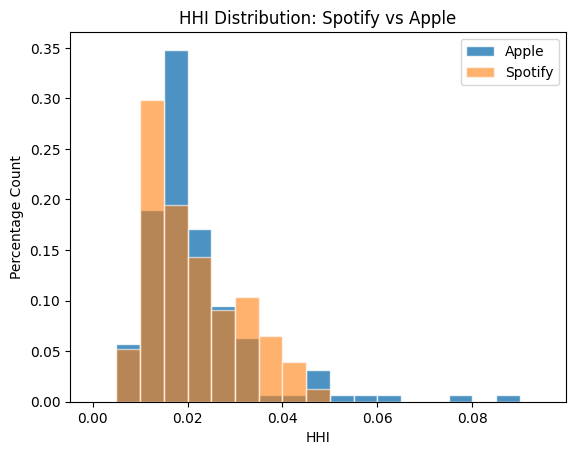

In [159]:
#Plot the HHI coefficients for both the apple music and spotify charts

plt.hist(apple_csv["HHI"],  bins = np.arange(0, 0.1, 0.005), weights=np.ones(len(apple_csv)) / len(apple_csv), alpha = 0.8, edgecolor = "white", label = "Apple")
plt.hist(spotify_csv["HHI"], bins = np.arange(0, 0.1, 0.005), weights=np.ones(len(spotify_csv)) / len(spotify_csv), alpha = 0.6, edgecolor = "white", label = "Spotify")
plt.xlabel("HHI")
plt.ylabel("Percentage Count")
plt.title("HHI Distribution: Spotify vs Apple")
plt.legend()

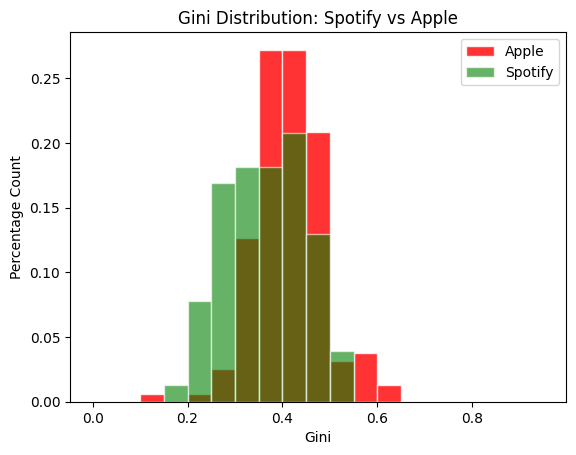

In [160]:
#Plot the Gini coefficients for both the apple music and spotify charts

plt.hist(apple_csv["Gini"],  bins = np.arange(0, 1, 0.05), weights=np.ones(len(apple_csv)) / len(apple_csv), alpha = 0.8, color = "red", edgecolor = "white", label = "Apple")
plt.hist(spotify_csv["Gini"], bins = np.arange(0, 1, 0.05), weights=np.ones(len(spotify_csv)) / len(spotify_csv), alpha = 0.6, color = "green", edgecolor = "white", label = "Spotify")
plt.xlabel("Gini")
plt.ylabel("Percentage Count")
plt.title("Gini Distribution: Spotify vs Apple")
plt.legend()

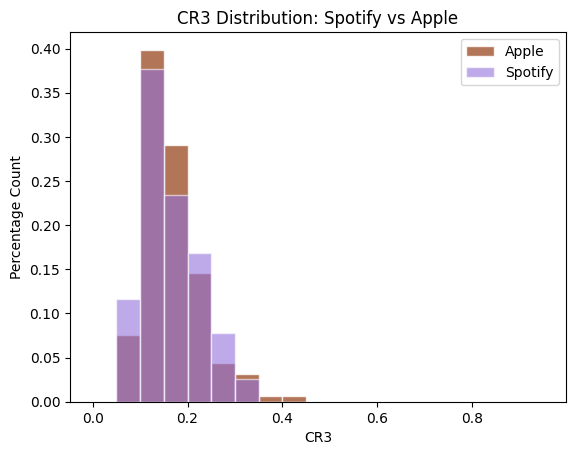

In [10]:
#Plot the CR3 coefficients for both the apple music and spotify charts

plt.hist(apple_csv["CR3"],  bins = np.arange(0, 1, 0.05), weights=np.ones(len(apple_csv)) / len(apple_csv), alpha = 0.8, color = "sienna", edgecolor = "white", label = "Apple")
plt.hist(spotify_csv["CR3"], bins = np.arange(0, 1, 0.05), weights=np.ones(len(spotify_csv)) / len(spotify_csv), alpha = 0.6, color = "mediumpurple", edgecolor = "white", label = "Spotify")
plt.xlabel("CR3")
plt.ylabel("Percentage Count")
plt.title("CR3 Distribution: Spotify vs Apple")
plt.legend()